In [11]:
import cv2
import numpy as np
import os
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------------------
# CONFIGURATION
# ---------------------------
KITTI_PATH = "/Users/mayuri/Downloads/dataset/sequences/00/image_0"  # e.g. ./dataset/sequences/00/image_2/
N_IMAGES = 300          # Limit number of images for demo/testing
ORB_FEATURES = 1000     # Number of ORB keypoints per image
RESIZE_TO = (640, 192)  # Resize for consistent feature scale

# ---------------------------
# 1. Load KITTI Images
# ---------------------------
def load_images(path, n_images):
    """Load grayscale KITTI images"""
    images = []
    filenames = sorted(os.listdir(path))[:n_images]
    for f in filenames:
        img = cv2.imread(os.path.join(path, f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        images.append(gray)
    return images, filenames

In [12]:
# ---------------------------
# 2. Image Preprocessing
# ---------------------------
def preprocess_image(img):
    """
    Perform standard preprocessing:
    1. Resize to a fixed size
    2. Histogram equalization to normalize lighting
    3. Gaussian blur to reduce noise
    """
    # Resize
    img_resized = cv2.resize(img, RESIZE_TO)
    # Histogram equalization
    img_eq = cv2.equalizeHist(img_resized)
    # Denoise slightly
    img_blur = cv2.GaussianBlur(img_eq, (3, 3), 0)
    return img_blur

def preprocess_images(images):
    preprocessed = []
    for img in tqdm(images, desc="Preprocessing images"):
        preprocessed.append(preprocess_image(img))
    return preprocessed

In [13]:
# ---------------------------
# 3. Feature Extraction (ORB)
# ---------------------------
def extract_features(images):
    orb = cv2.ORB_create(nfeatures=ORB_FEATURES)
    descriptors = []
    keypoints_all = []
    for img in tqdm(images, desc="Extracting features"):
        kp, des = orb.detectAndCompute(img, None)
        keypoints_all.append(kp)
        descriptors.append(des)
    return keypoints_all, descriptors

# ---------------------------
# 4. Feature Matching (Brute Force)
# ---------------------------
def match_features(des1, des2):
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    return matches

In [14]:
# ---------------------------
# 5. Compute Similarity Matrix
# ---------------------------
def compute_similarity(descriptors):
    n = len(descriptors)
    similarity = np.zeros((n, n))
    for i in tqdm(range(n), desc="Computing similarity"):
        for j in range(i + 1, n):
            if descriptors[i] is None or descriptors[j] is None:
                continue
            matches = match_features(descriptors[i], descriptors[j])
            similarity[i, j] = similarity[j, i] = len(matches)
    return similarity


In [15]:
# ---------------------------
# 6. Detect Revisits (Simple Threshold)
# ---------------------------
def detect_revisits(similarity, threshold):
    n = len(similarity)
    predicted = []
    actual = []
    for i in range(n):
        for j in range(i + 20, n):  # skip nearby frames to avoid trivial matches
            sim_score = similarity[i, j]
            is_revisit = 1 if sim_score > threshold else 0
            predicted.append(is_revisit)
            # For demonstration: frames < 3 apart = same location
            actual.append(1 if abs(i - j) < 3 else 0)
    return np.array(actual), np.array(predicted)


In [16]:
# ---------------------------
# 7. Evaluation: Precision, Recall, AUC
# ---------------------------
def evaluate(similarity):
    y_true, y_scores = [], []
    n = len(similarity)
    for i in range(n):
        for j in range(i + 20, n):
            y_scores.append(similarity[i, j])
            #y_true.append(1 if abs(i - j) < 3 else 0)
            # Example: mark same place every 50 frames (fake revisits)
            y_true.append(1 if (i // 50) == (j // 50) else 0)

    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    auc_score = auc(recall, precision)
    return precision, recall, auc_score

📂 Loading images...
🧼 Preprocessing images...


Preprocessing images: 100%|██████████| 300/300 [00:00<00:00, 2821.30it/s]


🔍 Extracting features...


Extracting features: 100%|██████████| 300/300 [00:01<00:00, 219.99it/s]


🔗 Computing similarity matrix...


Computing similarity: 100%|██████████| 300/300 [02:28<00:00,  2.03it/s]


📊 Evaluating performance...

✅ AUC (Precision-Recall): 15.30%


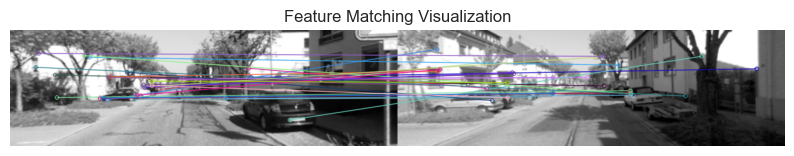

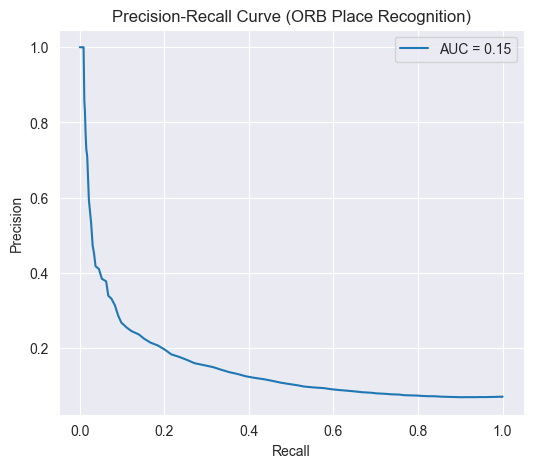

In [17]:
# ---------------------------
# 8. Visualization
# ---------------------------
def visualize_matches(img1, img2, kp1, kp2, matches):
    matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:30], None, flags=2)
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.title("Feature Matching Visualization")
    plt.axis("off")
    plt.show()

# ---------------------------
# MAIN PIPELINE
# ---------------------------
if __name__ == "__main__":
    print("📂 Loading images...")
    images, names = load_images(KITTI_PATH, N_IMAGES)

    print("🧼 Preprocessing images...")
    preprocessed_images = preprocess_images(images)

    print("🔍 Extracting features...")
    keypoints_all, descriptors = extract_features(preprocessed_images)

    print("🔗 Computing similarity matrix...")
    similarity = compute_similarity(descriptors)

    print("📊 Evaluating performance...")
    precision, recall, auc_score = evaluate(similarity)
    print(f"\n✅ AUC (Precision-Recall): {auc_score * 100:.2f}%")

    # Example visualization
    idx1, idx2 = 0, 50
    matches = match_features(descriptors[idx1], descriptors[idx2])
    visualize_matches(preprocessed_images[idx1], preprocessed_images[idx2],
                      keypoints_all[idx1], keypoints_all[idx2], matches)

    # Plot Precision-Recall curve
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {auc_score:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (ORB Place Recognition)")
    plt.legend()
    plt.grid(True)
    plt.show()